## 1. Chargement des donnees

Cette cellule charge le fichier CSV du site 004 dans un DataFrame pandas. Elle verifie aussi que le fichier existe, convertit cquisition_date en vraie date, puis affiche les cinq premieres lignes avec df.head() pour controler rapidement le contenu.

In [63]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from pyproj import Transformer
from rasterio.mask import mask
from rasterio.plot import show
from shapely.geometry import mapping, shape
from shapely.ops import transform as shapely_transform


PROJECT_ROOT = Path.cwd().parent

CSV_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "vegetation_timeseries_site_004.csv"
)

print(CSV_FILE)
print("Existe :", CSV_FILE.exists())

df = pd.read_csv(
    CSV_FILE,
    parse_dates=["acquisition_date"],
)

df.head()

d:\Compte ASUS\Desktop\Eve\data\processed\vegetation_timeseries_site_004.csv
Existe : True


,site_id,name,crop_type,acquisition_date,acquisition_count,product_ids,acquisition_datetimes,tile_cloud_cover_min,tile_cloud_cover_mean,tile_cloud_cover_max,...,ratio_ndre_below_0,ratio_ndre_0_0_2,ratio_ndre_0_2_0_4,ratio_ndre_0_4_0_6,ratio_ndre_0_6_0_8,ratio_ndre_above_0_8,ndre_is_usable,ndre_change_from_previous_usable,ndre_rolling_mean_3,usable_all_indices
0,site_004,Parcelle noyers,noyers,2015-07-30,2,S2A_MSIL2A_20150730T103016_N0500_R108_T31TFK_2...,2015-07-30T10:38:22.693000+00:00 | 2015-07-30T...,55.63,61.245,66.86,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
1,site_004,Parcelle noyers,noyers,2015-08-02,2,S2A_MSIL2A_20150802T104026_N0500_R008_T31TFK_2...,2015-08-02T10:48:20.238000+00:00 | 2015-08-02T...,3.77,4.865,5.96,...,0.0,0.0,0.073684,0.515789,0.410526,0.0,False,NaN,NaN,False
2,site_004,Parcelle noyers,noyers,2015-08-09,2,S2A_MSIL2A_20150809T103016_N0500_R108_T31TFK_2...,2015-08-09T10:38:24.101000+00:00 | 2015-08-09T...,62.76,77.795,92.83,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
3,site_004,Parcelle noyers,noyers,2015-08-12,2,S2A_MSIL2A_20150812T104026_N0500_R008_T31TFK_2...,2015-08-12T10:48:21.274000+00:00 | 2015-08-12T...,1.02,1.220,1.42,...,0.0,0.0,0.049080,0.472393,0.478528,0.0,True,NaN,0.581280,True
4,site_004,Parcelle noyers,noyers,2015-08-19,2,S2A_MSIL2A_20150819T103026_N0500_R108_T31TFK_2...,2015-08-19T10:38:24.358000+00:00 | 2015-08-19T...,5.06,5.895,6.73,...,0.0,0.0,0.030675,0.282209,0.687117,0.0,True,0.032289,0.597424,True


## 2. Controle des colonnes et valeurs manquantes

Cette cellule construit un tableau de synthese pour chaque colonne : son nom, son type, le nombre de valeurs presentes et le nombre de valeurs manquantes. C est le premier diagnostic pour reperer les colonnes incompletes.

In [64]:
column_info = pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "valeurs_manquantes": df.isna().sum().values,
})

column_info

,colonne,type,non_null,valeurs_manquantes
0,site_id,str,1479,0
1,name,str,1479,0
2,crop_type,str,1479,0
3,acquisition_date,datetime64[us],1479,0
4,acquisition_count,int64,1479,0
...,...,...,...,...
98,ratio_ndre_above_0_8,float64,758,721
99,ndre_is_usable,bool,1479,0
100,ndre_change_from_previous_usable,float64,676,803
101,ndre_rolling_mean_3,float64,677,802


## 3. Statistiques descriptives globales

Cette cellule affiche les statistiques numeriques principales du DataFrame : moyenne, ecart-type, minimum, quartiles et maximum. Elle sert a verifier les ordres de grandeur des indices et a reperer d eventuelles valeurs extremes.

In [65]:
df.describe()

,acquisition_date,acquisition_count,tile_cloud_cover_min,tile_cloud_cover_mean,tile_cloud_cover_max,ndvi_geometry_pixel_count,ndvi_sample_count,ndvi_no_data_count,ndvi_valid_pixel_count,ndvi_valid_pixel_ratio,...,ndre_p75,ndre_p90,ratio_ndre_below_0,ratio_ndre_0_0_2,ratio_ndre_0_2_0_4,ratio_ndre_0_4_0_6,ratio_ndre_0_6_0_8,ratio_ndre_above_0_8,ndre_change_from_previous_usable,ndre_rolling_mean_3
count,1479,1479.000000,1479.000000,1479.000000,1479.000000,1479.0,1479.0,1479.000000,1479.000000,1479.000000,...,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.0,676.000000,677.000000
mean,2021-07-29 15:04:30.182555,2.081136,43.953489,52.053678,60.152366,570.0,868.0,601.110886,266.889114,0.468227,...,0.522825,0.554503,0.012712,0.025865,0.181845,0.621897,0.157681,0.0,-0.000022,0.491725
min,2015-07-30 00:00:00,1.000000,0.000000,0.000000,0.000000,570.0,868.0,298.000000,0.000000,0.000000,...,-0.034169,-0.034169,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.571326,0.128763
25%,2019-01-31 12:00:00,2.000000,9.005000,18.472500,26.660000,570.0,868.0,298.000000,0.000000,0.000000,...,0.477714,0.516012,0.000000,0.000000,0.024540,0.473932,0.000000,0.0,-0.021041,0.449917
50%,2021-08-12 00:00:00,2.000000,36.990000,54.880000,69.600000,570.0,868.0,850.000000,18.000000,0.031579,...,0.556518,0.590157,0.000000,0.000000,0.067485,0.693252,0.067076,0.0,0.001860,0.516637
75%,2024-03-03 00:00:00,2.000000,77.105000,85.362500,96.405000,570.0,868.0,868.000000,570.000000,1.000000,...,0.604192,0.636107,0.000000,0.000000,0.203391,0.825448,0.276074,0.0,0.021872,0.551989
max,2026-06-17 00:00:00,6.000000,100.000000,100.000000,100.000000,570.0,868.0,868.000000,570.000000,1.000000,...,0.676028,0.693215,1.000000,1.000000,1.000000,1.000000,0.760736,0.0,0.560201,0.614846
std,NaN,0.433901,35.582178,34.891233,35.951005,0.0,0.0,277.954217,277.954217,0.487639,...,0.120655,0.121943,0.103186,0.129640,0.254458,0.267389,0.188449,0.0,0.088385,0.082426


## 4. Creation du jeu de donnees propre

Cette cellule selectionne les quatre indices a suivre (NDVI, EVI, NDMI, NDRE) puis cree df_clean. On ne garde que les dates marquees comme utilisables pour tous les indices, sans valeurs manquantes, et triees chronologiquement.

In [66]:
indices = [
    "ndvi_mean",
    "evi_mean",
    "ndmi_mean",
    "ndre_mean",
]

df_clean = (
    df[df["usable_all_indices"]]
    .dropna(subset=indices)
    .sort_values("acquisition_date")
    .copy()
)

## 5. Agregation mensuelle des indices

Cette cellule transforme les observations propres en series mensuelles. Pour chaque mois, elle calcule la mediane des indices et ajoute le nombre d observations disponibles, afin de savoir si un mois est bien represente.

In [67]:
monthly = (
    df_clean
    .set_index("acquisition_date")[indices]
    .resample("MS")
    .median()
)

monthly["n_observations"] = (
    df_clean
    .set_index("acquisition_date")["ndvi_mean"]
    .resample("MS")
    .count()
)

monthly.head()

,ndvi_mean,evi_mean,ndmi_mean,ndre_mean,n_observations
acquisition_date,,,,,
2015-08-01,0.851609,0.655654,0.313889,0.607835,4
2015-09-01,0.788203,0.591383,0.251521,0.557209,3
2015-10-01,0.799536,0.567497,0.308736,0.542330,2
2015-11-01,NaN,NaN,NaN,NaN,0
2015-12-01,0.634183,0.340221,0.066959,0.428814,3


## 6. Statistiques annuelles sur la saison vegetative

Cette cellule se concentre sur la periode avril-octobre, plus pertinente pour suivre les noyers. Elle calcule ensuite, par annee, la mediane, la moyenne, l ecart-type et le nombre d observations de chaque indice.

In [68]:
growing_season = df_clean[
    df_clean["acquisition_date"].dt.month.between(4, 10)
].copy()

annual_stats = (
    growing_season
    .assign(
        year=growing_season["acquisition_date"].dt.year
    )
    .groupby("year")[indices]
    .agg(["median", "mean", "std", "count"])
)

annual_stats

ndvi_mean                            evi_mean                            \
        median      mean       std count    median      mean       std count   
year                                                                           
2015  0.808028  0.819708  0.033761     9  0.596700  0.610348  0.050881     9   
2016  0.806611  0.783896  0.081652    22  0.618292  0.590812  0.105288    22   
2017  0.774622  0.766311  0.078308    45  0.567163  0.561387  0.108483    45   
2018  0.775010  0.773621  0.050000    46  0.553893  0.554641  0.124645    46   
2019  0.776897  0.768339  0.111930    51  0.605789  0.596842  0.101088    51   
2020  0.759062  0.754676  0.061519    44  0.556911  0.569027  0.089667    44   
2021  0.770811  0.749232  0.130518    42  0.590940  0.575067  0.096182    42   
2022  0.779805  0.768900  0.035844    51  0.582636  0.578410  0.065556    51   
2023  0.794113  0.787849  0.058426    49  0.629043  0.620233  0.071721    49   
2024  0.759493  0.761582  0.068348    37  0.567147  0.577298  0.115379    37   
2025  0.792584  0.772547  0.072734    59  0.590752  0.577790  0.104102    59   
2026  0.775152  0.761280  0.080104    21  0.588597  0.591886  0.099659    21   

     ndmi_mean                           ndre_mean                            
        median      mean       std count    median      mean       std count  
year                                                                          
2015  0.288828  0.288927  0.032544     9  0.559005  0.575920  0.033083     9  
2016  0.274625  0.276078  0.071480    22  0.542133  0.523591  0.058995    22  
2017  0.220230  0.229672  0.081735    45  0.515953  0.518094  0.064493    45  
2018  0.226698  0.236043  0.071273    46  0.536649  0.534440  0.032958    46  
2019  0.276307  0.273345  0.084098    51  0.553438  0.542220  0.081490    51  
2020  0.221096  0.237283  0.068582    44  0.534585  0.528317  0.048073    44  
2021  0.272031  0.256507  0.066109    42  0.541509  0.529343  0.097021    42  
2022  0.244155  0.240650  0.049322    51  0.532787  0.530074  0.034046    51  
2023  0.273170  0.281460  0.054060    49  0.561137  0.554068  0.040259    49  
2024  0.251969  0.268752  0.066110    37  0.522987  0.525799  0.039922    37  
2025  0.273815  0.257156  0.071245    59  0.531950  0.515517  0.063247    59  
2026  0.278182  0.263531  0.085572    21  0.506597  0.496536  0.061624    21

## 7. Profil mensuel moyen sur toutes les annees

Cette cellule regroupe toutes les observations par mois, toutes annees confondues. Elle permet de comprendre le cycle saisonnier habituel de la parcelle : reprise, pic de vegetation, puis baisse en fin de saison.

In [69]:
monthly_climatology = (
    df_clean
    .assign(
        month=df_clean["acquisition_date"].dt.month
    )
    .groupby("month")[indices]
    .agg(["median", "std", "count"])
)

monthly_climatology

ndvi_mean                  evi_mean                 ndmi_mean            \
         median       std count    median       std count    median       std   
month                                                                           
1      0.550253  0.170544    27  0.335492  0.091426    27  0.077442  0.075876   
2      0.641711  0.110691    52  0.396105  0.070368    52  0.105240  0.067883   
3      0.701377  0.066881    49  0.490125  0.064248    49  0.200823  0.048469   
4      0.719761  0.068555    63  0.524811  0.078605    63  0.246895  0.078700   
5      0.813891  0.069416    57  0.678232  0.096812    57  0.320489  0.066934   
6      0.811200  0.044852    77  0.662635  0.058031    77  0.304022  0.041952   
7      0.784193  0.050419    79  0.613188  0.063581    79  0.254643  0.046353   
8      0.778421  0.101449    80  0.574815  0.087510    80  0.231867  0.057275   
9      0.770061  0.037972    68  0.516407  0.048294    68  0.202221  0.048399   
10     0.768725  0.116970    52  0.488021  0.087496    52  0.203593  0.070787   
11     0.647167  0.139204    35  0.390959  0.096710    35  0.075318  0.096827   
12     0.589495  0.192321    38  0.319262  0.066491    38  0.065939  0.043922   

            ndre_mean                  
      count    median       std count  
month                                  
1        27  0.370153  0.118597    27  
2        52  0.426711  0.077895    52  
3        49  0.481748  0.045204    49  
4        63  0.491367  0.065073    63  
5        57  0.517165  0.052474    57  
6        77  0.562129  0.031796    77  
7        79  0.559590  0.034362    79  
8        80  0.553410  0.073060    80  
9        68  0.528935  0.023896    68  
10       52  0.511919  0.083104    52  
11       35  0.441988  0.089546    35  
12       38  0.395490  0.137854    38

## 8. Courbes brutes des indices utilisables

Cette cellule trace les quatre indices sur toutes les dates utilisables. C est la vue la plus detaillee de l evolution temporelle, avec les variations fines et les ruptures possibles entre deux observations.

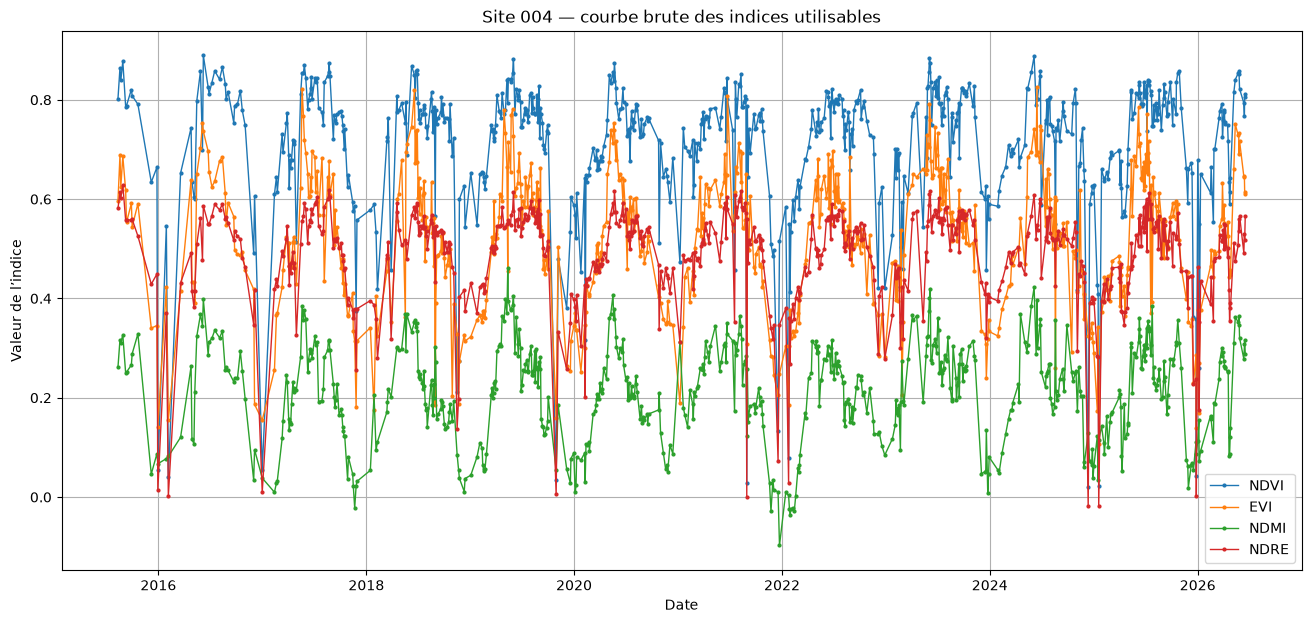

In [70]:
import matplotlib.pyplot as plt
import pandas as pd


indices = [
    "ndvi_mean",
    "evi_mean",
    "ndmi_mean",
    "ndre_mean",
]

df_clean = (
    df[
        df["usable_all_indices"]
    ]
    .dropna(subset=indices)
    .sort_values("acquisition_date")
    .copy()
)

plt.figure(figsize=(16, 7))

for column, label in [
    ("ndvi_mean", "NDVI"),
    ("evi_mean", "EVI"),
    ("ndmi_mean", "NDMI"),
    ("ndre_mean", "NDRE"),
]:
    plt.plot(
        df_clean["acquisition_date"],
        df_clean[column],
        marker="o",
        markersize=2,
        linewidth=1,
        label=label,
    )

plt.xlabel("Date")
plt.ylabel("Valeur de l’indice")
plt.title("Site 004 — courbe brute des indices utilisables")
plt.grid()
plt.legend()
plt.show()

## 9. Courbes mensuelles lissees

Cette cellule retrace les indices apres aggregation mensuelle par mediane. La courbe est moins bruitee que la courbe brute et convient mieux pour lire les tendances longues depuis 2015.

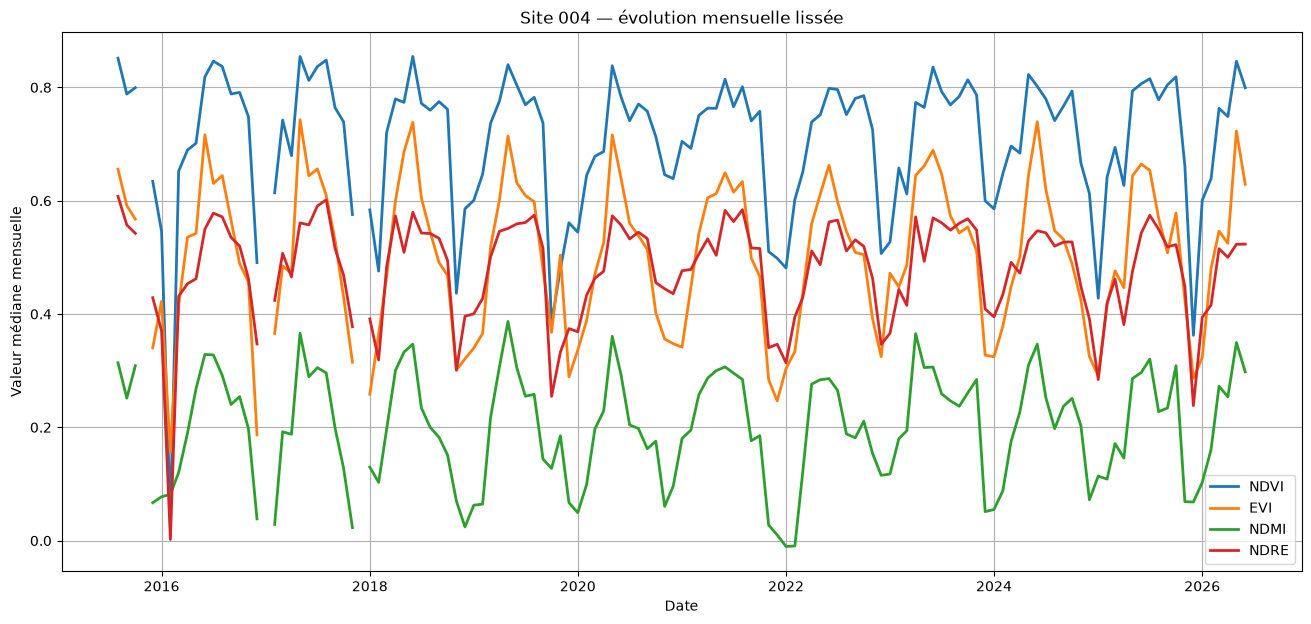

In [71]:
monthly = (
    df_clean
    .set_index("acquisition_date")[indices]
    .resample("MS")
    .median()
    .reset_index()
)

plt.figure(figsize=(16, 7))

for column, label in [
    ("ndvi_mean", "NDVI"),
    ("evi_mean", "EVI"),
    ("ndmi_mean", "NDMI"),
    ("ndre_mean", "NDRE"),
]:
    plt.plot(
        monthly["acquisition_date"],
        monthly[column],
        linewidth=2,
        label=label,
    )

plt.xlabel("Date")
plt.ylabel("Valeur médiane mensuelle")
plt.title("Site 004 — évolution mensuelle lissée")
plt.grid()
plt.legend()
plt.show()

## 10. Comparaison saisonniere du NDVI par annee

Cette cellule compare le profil mensuel du NDVI entre les annees. Chaque courbe represente une annee, ce qui aide a voir si la parcelle demarre plus tot, atteint un pic plus fort, ou decline plus vite selon les saisons.

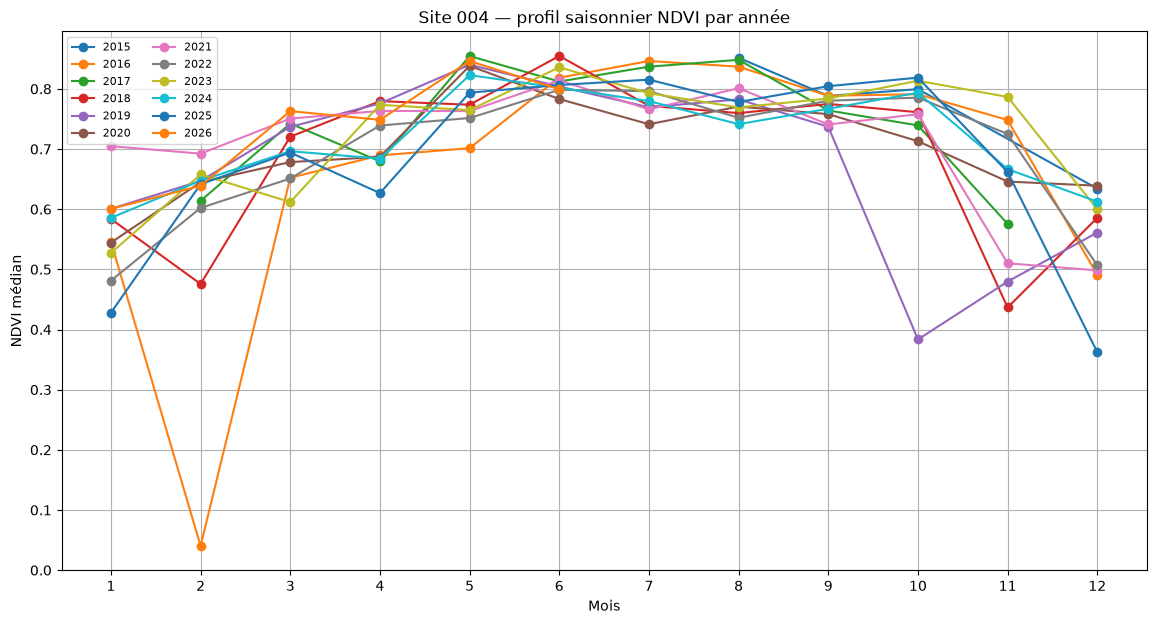

In [72]:
season_df = df_clean.copy()
season_df["year"] = season_df["acquisition_date"].dt.year
season_df["month"] = season_df["acquisition_date"].dt.month

season_monthly = (
    season_df
    .groupby(["year", "month"])["ndvi_mean"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for year in sorted(season_monthly["year"].unique()):
    year_data = season_monthly[
        season_monthly["year"] == year
    ]
    plt.plot(
        year_data["month"],
        year_data["ndvi_mean"],
        marker="o",
        linewidth=1.5,
        label=str(year),
    )

plt.xlabel("Mois")
plt.ylabel("NDVI médian")
plt.title("Site 004 — profil saisonnier NDVI par année")
plt.xticks(range(1, 13))
plt.grid()
plt.legend(ncol=2, fontsize=8)
plt.show()

In [73]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR


SITE_ID = "site_004"
INDEX_NAME = "ndmi"

BUFFER_DISTANCES = [
    0,
    10,
    20,
]


PARCELS_FILE = (
    PROJECT_ROOT
    / "data"
    / "input"
    / "parcels.geojson"
)

TIFF_DIR = (
    PROJECT_ROOT
    / "data"
    / "output"
    / "rasters"
    / SITE_ID
    / INDEX_NAME
)

TIFF_FILES = sorted(
    TIFF_DIR.glob(f"*_{INDEX_NAME}.tif")
)

print("Nombre de TIFF trouvés :", len(TIFF_FILES))

if not TIFF_FILES:
    raise FileNotFoundError(
        f"Aucun TIFF trouvé dans : {TIFF_DIR}"
    )

TIFF_FILES[:5]

Nombre de TIFF trouvés : 1


[WindowsPath('d:/Compte ASUS/Desktop/Eve/data/output/rasters/site_004/ndmi/2025-06-25_ndmi.tif')]

In [74]:
with PARCELS_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    parcels_geojson = json.load(file)


selected_feature = None

for feature in parcels_geojson["features"]:
    properties = feature.get(
        "properties",
        {},
    )

    if properties.get("site_id") == SITE_ID:
        selected_feature = feature
        break


if selected_feature is None:
    raise ValueError(
        f"Parcelle inconnue : {SITE_ID}"
    )


parcel_wgs84 = shape(
    selected_feature["geometry"]
)

print("Parcelle :", selected_feature["properties"])

Parcelle : {'site_id': 'site_004', 'name': 'Parcelle noyers', 'crop_type': 'noyers'}


In [75]:
REFERENCE_TIFF = TIFF_FILES[0]

with rasterio.open(REFERENCE_TIFF) as dataset:
    raster_crs = dataset.crs

print("TIFF de référence :", REFERENCE_TIFF.name)
print("CRS du raster :", raster_crs)


transformer = Transformer.from_crs(
    "EPSG:4326",
    raster_crs,
    always_xy=True,
)


parcel_projected = shapely_transform(
    transformer.transform,
    parcel_wgs84,
)

print(
    "Surface originale :",
    round(parcel_projected.area, 1),
    "m²",
)

TIFF de référence : 2025-06-25_ndmi.tif
CRS du raster : EPSG:32631
Surface originale : 51917.8 m²


In [76]:
buffered_geometries = {}


for buffer_m in BUFFER_DISTANCES:
    if buffer_m == 0:
        reduced_geometry = parcel_projected
    else:
        reduced_geometry = parcel_projected.buffer(
            -buffer_m
        )

    if reduced_geometry.is_empty:
        print(
            f"Buffer -{buffer_m} m ignoré : "
            "la parcelle disparaît."
        )
        continue

    if not reduced_geometry.is_valid:
        reduced_geometry = reduced_geometry.buffer(0)

    buffered_geometries[buffer_m] = (
        reduced_geometry
    )


for buffer_m, geometry in buffered_geometries.items():
    retained_ratio = (
        geometry.area
        / parcel_projected.area
    )

    print(
        f"Buffer -{buffer_m:>2} m | "
        f"surface = {geometry.area:.1f} m² | "
        f"surface conservée = {retained_ratio:.1%}"
    )

Buffer - 0 m | surface = 51917.9 m² | surface conservée = 100.0%
Buffer -10 m | surface = 42644.3 m² | surface conservée = 82.1%
Buffer -20 m | surface = 34255.9 m² | surface conservée = 66.0%


In [77]:
import os
from datetime import date, datetime, timedelta, timezone

import pandas as pd
import requests
from dotenv import load_dotenv
from shapely.geometry import mapping


load_dotenv(PROJECT_ROOT / ".env")


TOKEN_URL = (
    "https://identity.dataspace.copernicus.eu/"
    "auth/realms/CDSE/protocol/openid-connect/token"
)

STATISTICS_URL = (
    "https://sh.dataspace.copernicus.eu/statistics/v1"
)

SITE_ID = "site_004"

START_DATE = date.fromisoformat("2015-07-01")
END_DATE = date.fromisoformat("2026-06-18")

RESOLUTION_METERS = 20
MIN_VALID_PIXEL_RATIO = 0.70


def get_access_token() -> str:
    client_id = os.getenv("COPERNICUS_CLIENT_ID")
    client_secret = os.getenv("COPERNICUS_CLIENT_SECRET")

    if not client_id or not client_secret:
        raise RuntimeError(
            "Identifiants Copernicus absents du fichier .env."
        )

    response = requests.post(
        TOKEN_URL,
        data={
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret,
        },
        timeout=30,
    )

    if not response.ok:
        raise RuntimeError(
            "Échec de l'authentification : "
            f"{response.status_code} - {response.text}"
        )

    token = response.json().get("access_token")

    if not token:
        raise RuntimeError("Aucun token reçu.")

    return token


def to_utc_string(value: date) -> str:
    value_datetime = datetime(
        value.year,
        value.month,
        value.day,
        tzinfo=timezone.utc,
    )

    return value_datetime.strftime(
        "%Y-%m-%dT%H:%M:%SZ"
    )

In [78]:
NDMI_EVALSCRIPT = """
//VERSION=3

function setup() {
    return {
        input: [{
            bands: [
                "B08",
                "B11",
                "SCL",
                "dataMask"
            ]
        }],
        output: [
            {
                id: "ndmi",
                bands: 1,
                sampleType: "FLOAT32"
            },
            {
                id: "dataMask",
                bands: 1
            }
        ]
    };
}

function evaluatePixel(sample) {
    const invalidClasses = [
        0,
        1,
        3,
        8,
        9,
        10,
        11
    ];

    const denominator =
        sample.B08 + sample.B11;

    const validPixel =
        sample.dataMask === 1
        && denominator !== 0
        && !invalidClasses.includes(sample.SCL);

    if (!validPixel) {
        return {
            ndmi: [0],
            dataMask: [0]
        };
    }

    const ndmi = (
        sample.B08 - sample.B11
    ) / denominator;

    return {
        ndmi: [ndmi],
        dataMask: [1]
    };
}
"""

In [79]:
epsg_code = raster_crs.to_epsg()

if epsg_code is None:
    raise ValueError(
        "Impossible de récupérer le code EPSG du raster."
    )

STATISTICS_CRS_URL = (
    "http://www.opengis.net/"
    f"def/crs/EPSG/0/{epsg_code}"
)

print("CRS statistique :", STATISTICS_CRS_URL)


def generate_year_chunks(
    start_date: date,
    end_date: date,
):
    current_start = start_date

    while current_start <= end_date:
        current_end = min(
            date(current_start.year, 12, 31),
            end_date,
        )

        # La borne "to" de l'API est exclusive.
        end_exclusive = (
            current_end + timedelta(days=1)
        )

        yield current_start, end_exclusive

        current_start = end_exclusive

CRS statistique : http://www.opengis.net/def/crs/EPSG/0/32631


In [80]:
def request_ndmi_statistics(
    token: str,
    geometry,
    start_date: date,
    end_exclusive: date,
) -> dict:
    request_body = {
        "input": {
            "bounds": {
                "geometry": mapping(geometry),
                "properties": {
                    "crs": STATISTICS_CRS_URL
                },
            },
            "data": [
                {
                    "type": "sentinel-2-l2a",
                    "dataFilter": {
                        "mosaickingOrder": "leastCC",
                        "maxCloudCoverage": 100,
                    },
                }
            ],
        },
        "aggregation": {
            "timeRange": {
                "from": to_utc_string(start_date),
                "to": to_utc_string(end_exclusive),
            },
            "aggregationInterval": {
                "of": "P1D"
            },
            "evalscript": NDMI_EVALSCRIPT,
            "resx": RESOLUTION_METERS,
            "resy": RESOLUTION_METERS,
        },
        "calculations": {
            "ndmi": {
                "statistics": {
                    "default": {
                        "percentiles": {
                            "k": [
                                10,
                                25,
                                50,
                                75,
                                90,
                            ]
                        }
                    }
                }
            }
        },
    }

    response = requests.post(
        STATISTICS_URL,
        headers={
            "Authorization": f"Bearer {token}",
            "Content-Type": "application/json",
            "Accept": "application/json",
        },
        json=request_body,
        timeout=600,
    )

    if not response.ok:
        raise RuntimeError(
            "Échec Statistical API : "
            f"{response.status_code} - {response.text}"
        )

    return response.json()

In [81]:
def read_percentile(
    percentiles: dict,
    percentile: int,
):
    for key in (
        str(percentile),
        f"{percentile}.0",
    ):
        value = percentiles.get(key)

        if value is not None:
            return float(value)

    return None


def parse_statistics_response(
    response_data: dict,
    buffer_m: int,
    geometry,
) -> list[dict]:
    rows = []

    geometry_pixel_count = (
        response_data.get("geometryPixelCount")
    )

    for interval_data in response_data.get(
        "data",
        [],
    ):
        interval = interval_data.get(
            "interval",
            {},
        )

        outputs = interval_data.get(
            "outputs",
            {},
        )

        bands = (
            outputs
            .get("ndmi", {})
            .get("bands", {})
        )

        if not bands:
            continue

        band_data = next(
            iter(bands.values())
        )

        statistics = band_data.get(
            "stats",
            {},
        )

        sample_count = int(
            statistics.get(
                "sampleCount",
                0,
            ) or 0
        )

        no_data_count = int(
            statistics.get(
                "noDataCount",
                0,
            ) or 0
        )

        valid_pixel_count = max(
            sample_count - no_data_count,
            0,
        )

        valid_pixel_ratio = (
            min(
                valid_pixel_count
                / geometry_pixel_count,
                1.0,
            )
            if geometry_pixel_count
            else np.nan
        )

        percentiles = statistics.get(
            "percentiles",
            {},
        )

        rows.append(
            {
                "site_id": SITE_ID,
                "acquisition_date": interval.get(
                    "from",
                    "",
                )[:10],
                "index": "ndmi",
                "buffer_m": buffer_m,
                "area_m2": geometry.area,
                "area_retained_ratio": min(
                    geometry.area
                    / parcel_projected.area,
                    1.0,
                ),
                "geometry_pixel_count": (
                    geometry_pixel_count
                ),
                "sample_count": sample_count,
                "no_data_count": no_data_count,
                "valid_pixel_count": (
                    valid_pixel_count
                ),
                "valid_pixel_ratio": (
                    valid_pixel_ratio
                ),
                "mean": statistics.get("mean"),
                "median": read_percentile(
                    percentiles,
                    50,
                ),
                "std": statistics.get("stDev"),
                "minimum": statistics.get("min"),
                "maximum": statistics.get("max"),
                "p10": read_percentile(
                    percentiles,
                    10,
                ),
                "p25": read_percentile(
                    percentiles,
                    25,
                ),
                "p75": read_percentile(
                    percentiles,
                    75,
                ),
                "p90": read_percentile(
                    percentiles,
                    90,
                ),
            }
        )

    return rows

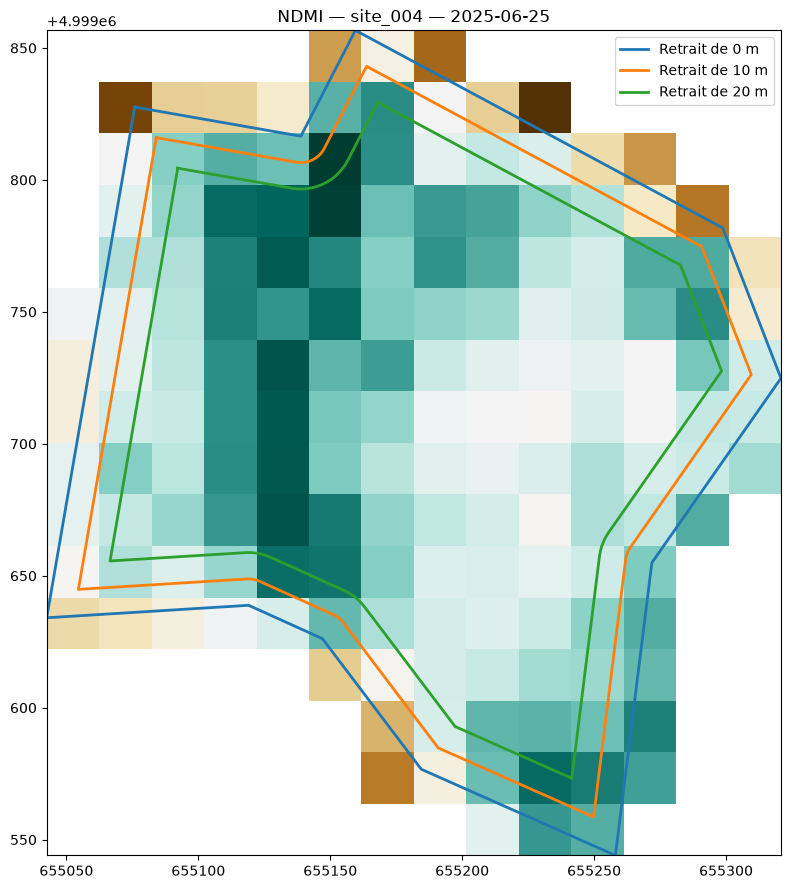

In [82]:
def draw_geometry_boundary(
    axis,
    geometry,
    label,
):
    geometries = (
        list(geometry.geoms)
        if geometry.geom_type == "MultiPolygon"
        else [geometry]
    )

    first_geometry = True

    for polygon in geometries:
        x_coordinates, y_coordinates = (
            polygon.exterior.xy
        )

        axis.plot(
            x_coordinates,
            y_coordinates,
            linewidth=2,
            label=label if first_geometry else None,
        )

        first_geometry = False


REFERENCE_DATE = (
    REFERENCE_TIFF.stem
    .replace(f"_{INDEX_NAME}", "")
)

figure, axis = plt.subplots(
    figsize=(10, 9)
)


with rasterio.open(REFERENCE_TIFF) as dataset:
    raster_values = dataset.read(
        1,
        masked=True,
    )

    raster_values = np.ma.masked_where(
        raster_values <= -9990,
        raster_values,
    )

    show(
        raster_values,
        transform=dataset.transform,
        ax=axis,
        cmap="BrBG",
    )


for buffer_m, geometry in buffered_geometries.items():
    draw_geometry_boundary(
        axis,
        geometry,
        label=f"Retrait de {buffer_m} m",
    )


axis.set_title(
    f"{INDEX_NAME.upper()} — {SITE_ID} — "
    f"{REFERENCE_DATE}"
)

axis.legend()
figure.tight_layout()

plt.show()

In [83]:
def calculate_raster_statistics(
    raster_file: Path,
    geometry,
) -> dict:
    with rasterio.open(raster_file) as dataset:
        raster_data, _ = mask(
            dataset,
            [mapping(geometry)],
            crop=True,
            filled=False,
        )

    values = raster_data[0]

    if np.ma.isMaskedArray(values):
        valid_values = values.compressed()
    else:
        valid_values = values.flatten()

    valid_values = valid_values[
        np.isfinite(valid_values)
        & (valid_values > -9990)
    ]

    if len(valid_values) == 0:
        return {
            "valid_pixel_count": 0,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "minimum": np.nan,
            "maximum": np.nan,
        }

    return {
        "valid_pixel_count": len(valid_values),
        "mean": float(valid_values.mean()),
        "median": float(np.median(valid_values)),
        "std": float(valid_values.std()),
        "minimum": float(valid_values.min()),
        "maximum": float(valid_values.max()),
    }

In [84]:
token = get_access_token()

records = []

for buffer_m, geometry in buffered_geometries.items():
    print()
    print(f"Traitement du buffer {buffer_m} m")

    for chunk_start, chunk_end in generate_year_chunks(
        START_DATE,
        END_DATE,
    ):
        print(
            f"  {chunk_start} → "
            f"{chunk_end - timedelta(days=1)}"
        )

        response_data = request_ndmi_statistics(
            token=token,
            geometry=geometry,
            start_date=chunk_start,
            end_exclusive=chunk_end,
        )

        records.extend(
            parse_statistics_response(
                response_data=response_data,
                buffer_m=buffer_m,
                geometry=geometry,
            )
        )


border_timeseries = pd.DataFrame(records)

border_timeseries["acquisition_date"] = (
    pd.to_datetime(
        border_timeseries["acquisition_date"],
        errors="coerce",
    )
)

border_timeseries["is_usable"] = (
    border_timeseries["mean"].notna()
    & (
        border_timeseries[
            "valid_pixel_ratio"
        ]
        >= MIN_VALID_PIXEL_RATIO
    )
)

border_timeseries = (
    border_timeseries
    .sort_values(
        [
            "acquisition_date",
            "buffer_m",
        ]
    )
    .reset_index(drop=True)
)

border_timeseries.head()


Traitement du buffer 0 m
  2015-07-01 → 2015-12-31
  2016-01-01 → 2016-12-31
  2017-01-01 → 2017-12-31
  2018-01-01 → 2018-12-31
  2019-01-01 → 2019-12-31
  2020-01-01 → 2020-12-31
  2021-01-01 → 2021-12-31
  2022-01-01 → 2022-12-31
  2023-01-01 → 2023-12-31
  2024-01-01 → 2024-12-31
  2025-01-01 → 2025-12-31
  2026-01-01 → 2026-06-18

Traitement du buffer 10 m
  2015-07-01 → 2015-12-31
  2016-01-01 → 2016-12-31
  2017-01-01 → 2017-12-31
  2018-01-01 → 2018-12-31
  2019-01-01 → 2019-12-31
  2020-01-01 → 2020-12-31
  2021-01-01 → 2021-12-31
  2022-01-01 → 2022-12-31
  2023-01-01 → 2023-12-31
  2024-01-01 → 2024-12-31
  2025-01-01 → 2025-12-31
  2026-01-01 → 2026-06-18

Traitement du buffer 20 m
  2015-07-01 → 2015-12-31
  2016-01-01 → 2016-12-31
  2017-01-01 → 2017-12-31
  2018-01-01 → 2018-12-31
  2019-01-01 → 2019-12-31
  2020-01-01 → 2020-12-31
  2021-01-01 → 2021-12-31
  2022-01-01 → 2022-12-31
  2023-01-01 → 2023-12-31
  2024-01-01 → 2024-12-31
  2025-01-01 → 2025-12-31
  2026-01-

,site_id,acquisition_date,index,buffer_m,area_m2,area_retained_ratio,geometry_pixel_count,sample_count,no_data_count,valid_pixel_count,...,mean,median,std,minimum,maximum,p10,p25,p75,p90,is_usable
0,site_004,2015-07-30,ndmi,0,51917.915995,1.000000,163,224,224,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,site_004,2015-07-30,ndmi,10,42644.307558,0.821382,132,182,182,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,site_004,2015-07-30,ndmi,20,34255.874947,0.659810,111,156,156,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,site_004,2015-08-02,ndmi,0,51917.915995,1.000000,163,224,129,95,...,0.295776,0.323659,0.126571,-0.205128,0.474195,0.094367,0.242912,0.388889,0.423181,False
4,site_004,2015-08-02,ndmi,10,42644.307558,0.821382,132,182,118,64,...,0.373089,0.398731,0.124244,-0.016244,0.606963,0.241379,0.318217,0.455290,0.486744,False


## 7. Correction locale des statistiques de bordure

In [85]:
import numpy as np
import pandas as pd


LOCAL_BORDER_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / f"border_ndmi_timeseries_{SITE_ID}.csv"
)

if "border_timeseries" not in globals():
    border_timeseries = pd.read_csv(
        LOCAL_BORDER_FILE,
        parse_dates=["acquisition_date"],
    )
    print("Série chargée depuis le CSV local :", LOCAL_BORDER_FILE)


numeric_columns = [
    "buffer_m",
    "area_m2",
    "area_retained_ratio",
    "geometry_pixel_count",
    "sample_count",
    "no_data_count",
    "valid_pixel_count",
    "valid_pixel_ratio",
    "mean",
    "median",
    "std",
    "minimum",
    "maximum",
    "p10",
    "p25",
    "p75",
    "p90",
]

for column in numeric_columns:
    if column in border_timeseries.columns:
        border_timeseries[column] = pd.to_numeric(
            border_timeseries[column],
            errors="coerce",
        )

border_timeseries["acquisition_date"] = pd.to_datetime(
    border_timeseries["acquisition_date"],
    errors="coerce",
)

border_timeseries["valid_pixel_count"] = (
    border_timeseries["sample_count"]
    - border_timeseries["no_data_count"]
).clip(lower=0)

border_timeseries["valid_pixel_ratio"] = np.where(
    border_timeseries["geometry_pixel_count"] > 0,
    (
        border_timeseries["valid_pixel_count"]
        / border_timeseries["geometry_pixel_count"]
    ),
    np.nan,
)

border_timeseries["valid_pixel_ratio"] = (
    border_timeseries["valid_pixel_ratio"]
    .clip(lower=0, upper=1)
)

MIN_VALID_PIXEL_RATIO = 0.70

border_timeseries["is_usable"] = (
    border_timeseries["mean"].notna()
    & border_timeseries["median"].notna()
    & (
        border_timeseries["valid_pixel_ratio"]
        >= MIN_VALID_PIXEL_RATIO
    )
)

quality_check = (
    border_timeseries
    .groupby("buffer_m")
    .agg(
        total_dates=("acquisition_date", "nunique"),
        dates_avec_valeur=("mean", "count"),
        dates_utilisables=("is_usable", "sum"),
        ratio_valide_moyen=("valid_pixel_ratio", "mean"),
    )
)

quality_check

,total_dates,dates_avec_valeur,dates_utilisables,ratio_valide_moyen
buffer_m,,,,
0,1479,758,677,0.468104
10,1479,750,678,0.468140
20,1479,744,681,0.468706


## 8. Sauvegarde de la série temporelle NDMI corrigée

In [86]:
OUTPUT_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / f"border_ndmi_timeseries_{SITE_ID}.csv"
)

OUTPUT_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

border_timeseries.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8",
)

print("CSV corrigé :", OUTPUT_FILE)
print("Nombre de lignes :", len(border_timeseries))
print(
    "Nombre de dates :",
    border_timeseries[
        "acquisition_date"
    ].nunique(),
)

CSV corrigé : d:\Compte ASUS\Desktop\Eve\data\processed\border_ndmi_timeseries_site_004.csv
Nombre de lignes : 4437
Nombre de dates : 1479


## 9. Résumé par buffer

In [87]:
usable_border = border_timeseries[
    border_timeseries["is_usable"]
].copy()

buffer_summary = (
    usable_border
    .groupby("buffer_m")
    .agg(
        dates_utilisables=(
            "acquisition_date",
            "nunique",
        ),
        surface_m2=(
            "area_m2",
            "first",
        ),
        surface_conservee=(
            "area_retained_ratio",
            "first",
        ),
        pixels_geometriques=(
            "geometry_pixel_count",
            "median",
        ),
        pixels_valides_moyens=(
            "valid_pixel_count",
            "mean",
        ),
        ndmi_moyen=(
            "mean",
            "mean",
        ),
        ndmi_median=(
            "median",
            "median",
        ),
        heterogeneite_moyenne=(
            "std",
            "mean",
        ),
    )
)

buffer_summary

,dates_utilisables,surface_m2,surface_conservee,pixels_geometriques,pixels_valides_moyens,ndmi_moyen,ndmi_median,heterogeneite_moyenne
buffer_m,,,,,,,,
0,677,51917.915995,1.000000,163.0,161.471196,0.215970,0.236968,0.098420
10,678,42644.307558,0.821382,132.0,130.915929,0.221503,0.246559,0.086777
20,681,34255.874947,0.659810,111.0,110.107195,0.227499,0.252434,0.081697


## 10. Comparaison sur les dates communes aux trois buffers

In [88]:
usable_counts = (
    usable_border
    .groupby("acquisition_date")["buffer_m"]
    .nunique()
)

common_dates = usable_counts[
    usable_counts == 3
].index

common_border = usable_border[
    usable_border["acquisition_date"].isin(
        common_dates
    )
].copy()

print(
    "Dates communes aux trois buffers :",
    len(common_dates),
)

common_summary = (
    common_border
    .groupby("buffer_m")
    .agg(
        dates=("acquisition_date", "nunique"),
        mean_ndmi=("mean", "mean"),
        median_ndmi=("median", "median"),
        spatial_std=("std", "mean"),
        valid_pixels=("valid_pixel_count", "mean"),
    )
)

common_summary

Dates communes aux trois buffers : 676


,dates,mean_ndmi,median_ndmi,spatial_std,valid_pixels
buffer_m,,,,,
0,676,0.215883,0.236681,0.098402,161.534024
10,676,0.221458,0.246559,0.086754,131.025148
20,676,0.227524,0.252397,0.081775,110.331361


## 11. Courbes mensuelles sur onze ans

In [89]:
if "monthly_border" in globals():
    del monthly_border

monthly_border = (
    common_border
    .set_index("acquisition_date")
    .groupby("buffer_m")
    .resample("MS")
    .agg(
        mean=("mean", "median"),
        median=("median", "median"),
        spatial_std=("std", "median"),
        valid_pixel_count=(
            "valid_pixel_count",
            "median",
        ),
        observations=("mean", "count"),
    )
    .reset_index()
)

monthly_border.head()

,buffer_m,acquisition_date,mean,median,spatial_std,valid_pixel_count,observations
0,0,2015-08-01,0.313889,0.340218,0.101332,163.0,4
1,0,2015-09-01,0.251521,0.270195,0.107824,163.0,3
2,0,2015-10-01,0.308736,0.324101,0.065090,163.0,2
3,0,2015-11-01,NaN,NaN,NaN,NaN,0
4,0,2015-12-01,0.066959,0.068079,0.149581,163.0,3


### Moyenne NDMI

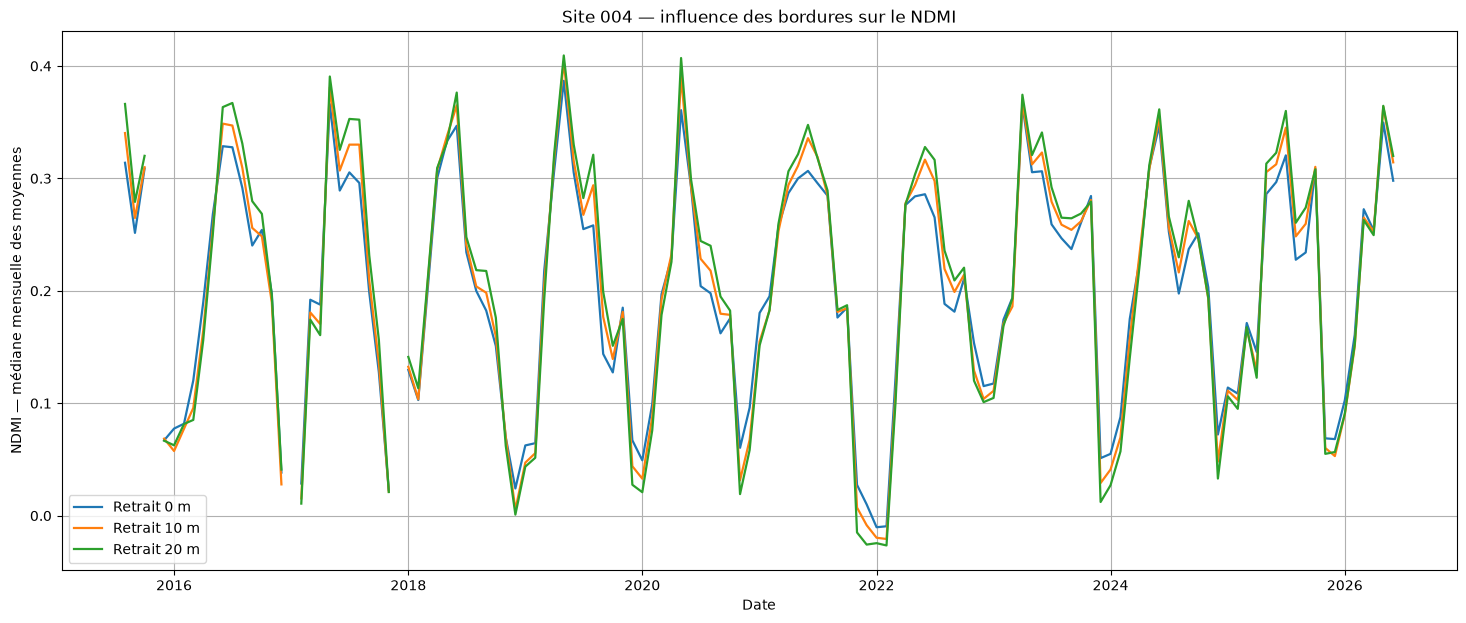

In [90]:
import matplotlib.pyplot as plt


plt.figure(figsize=(18, 7))

for buffer_m in [0, 10, 20]:
    current = monthly_border[
        monthly_border["buffer_m"]
        == buffer_m
    ]

    plt.plot(
        current["acquisition_date"],
        current["mean"],
        linewidth=1.6,
        label=f"Retrait {buffer_m} m",
    )

plt.xlabel("Date")
plt.ylabel("NDMI — médiane mensuelle des moyennes")
plt.title(
    "Site 004 — influence des bordures sur le NDMI"
)
plt.grid()
plt.legend()
plt.show()

### Médiane NDMI

<!-- Graphique des écarts déplacé après les courbes mensuelles. -->

In [91]:
# Graphique déplacé après les courbes mensuelles.

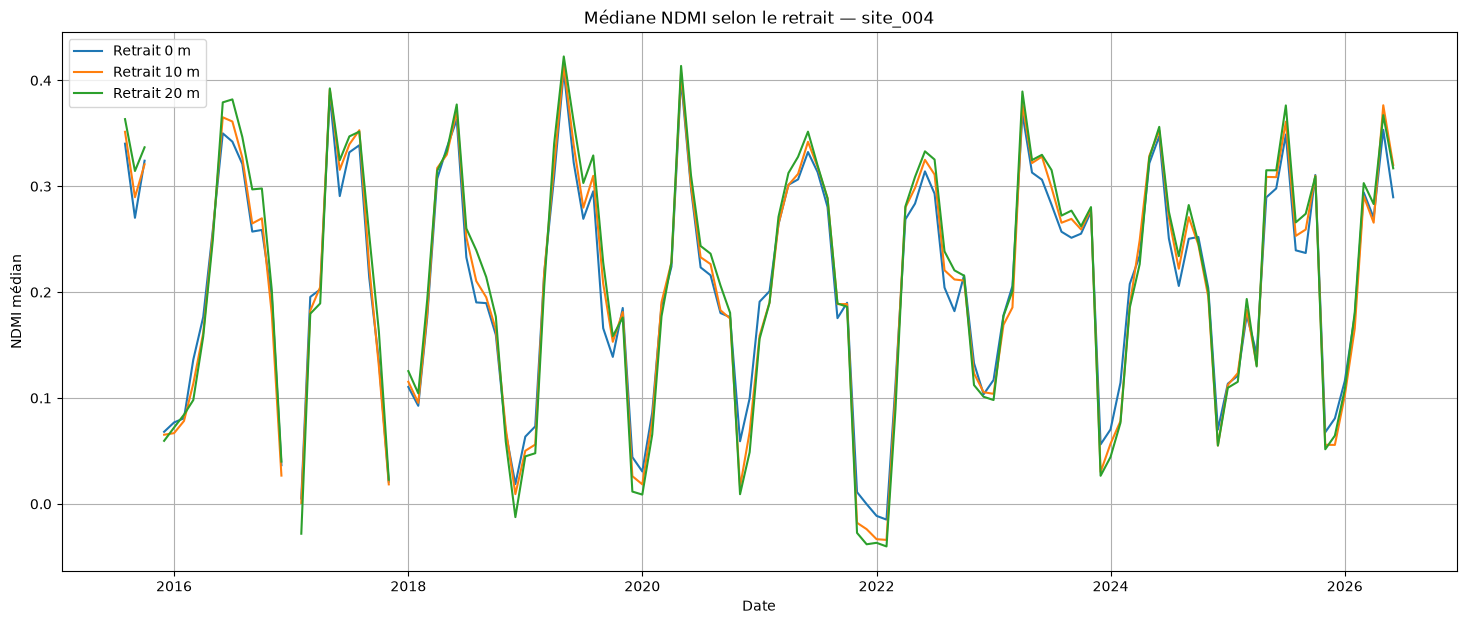

In [92]:
plt.figure(figsize=(18, 7))

for buffer_m in BUFFER_DISTANCES:
    current = monthly_border[
        monthly_border["buffer_m"]
        == buffer_m
    ]

    plt.plot(
        current["acquisition_date"],
        current["median"],
        linewidth=1.5,
        label=f"Retrait {buffer_m} m",
    )

plt.xlabel("Date")
plt.ylabel("NDMI médian")
plt.title(
    f"Médiane NDMI selon le retrait — {SITE_ID}"
)
plt.grid()
plt.legend()
plt.show()

### Nombre de pixels valides

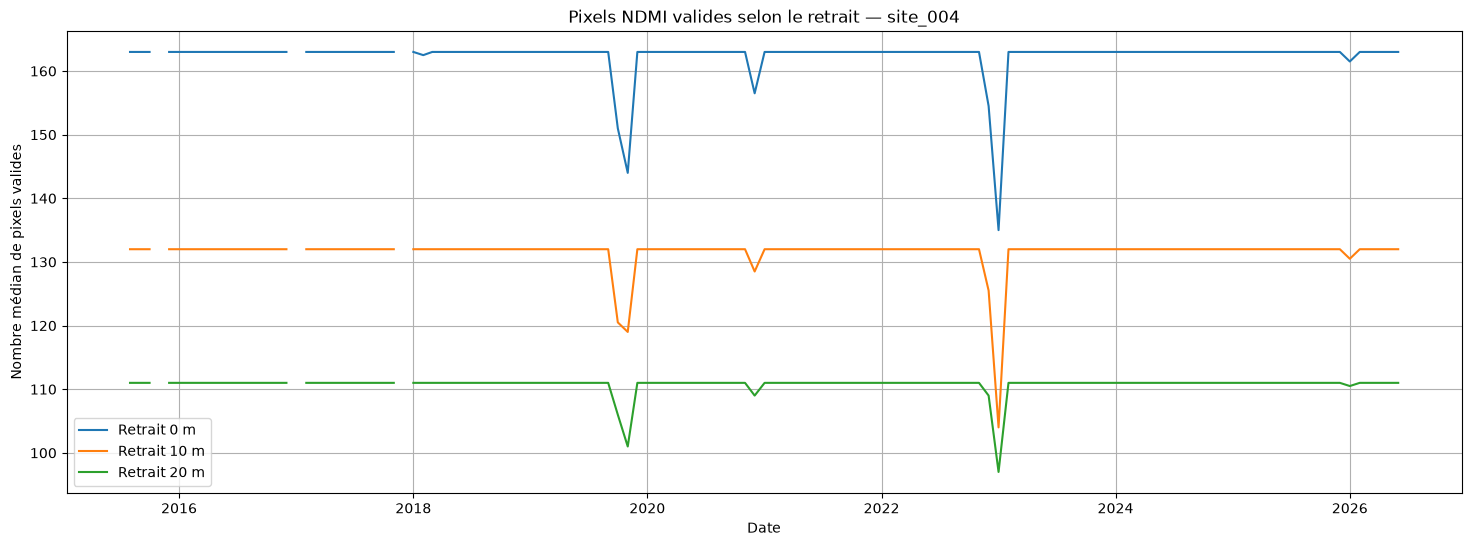

In [93]:
plt.figure(figsize=(18, 6))

for buffer_m in BUFFER_DISTANCES:
    current = monthly_border[
        monthly_border["buffer_m"]
        == buffer_m
    ]

    plt.plot(
        current["acquisition_date"],
        current["valid_pixel_count"],
        linewidth=1.5,
        label=f"Retrait {buffer_m} m",
    )

plt.xlabel("Date")
plt.ylabel("Nombre médian de pixels valides")
plt.title(
    f"Pixels NDMI valides selon le retrait — {SITE_ID}"
)
plt.grid()
plt.legend()
plt.show()

### Écart temporel causé par le retrait des bordures

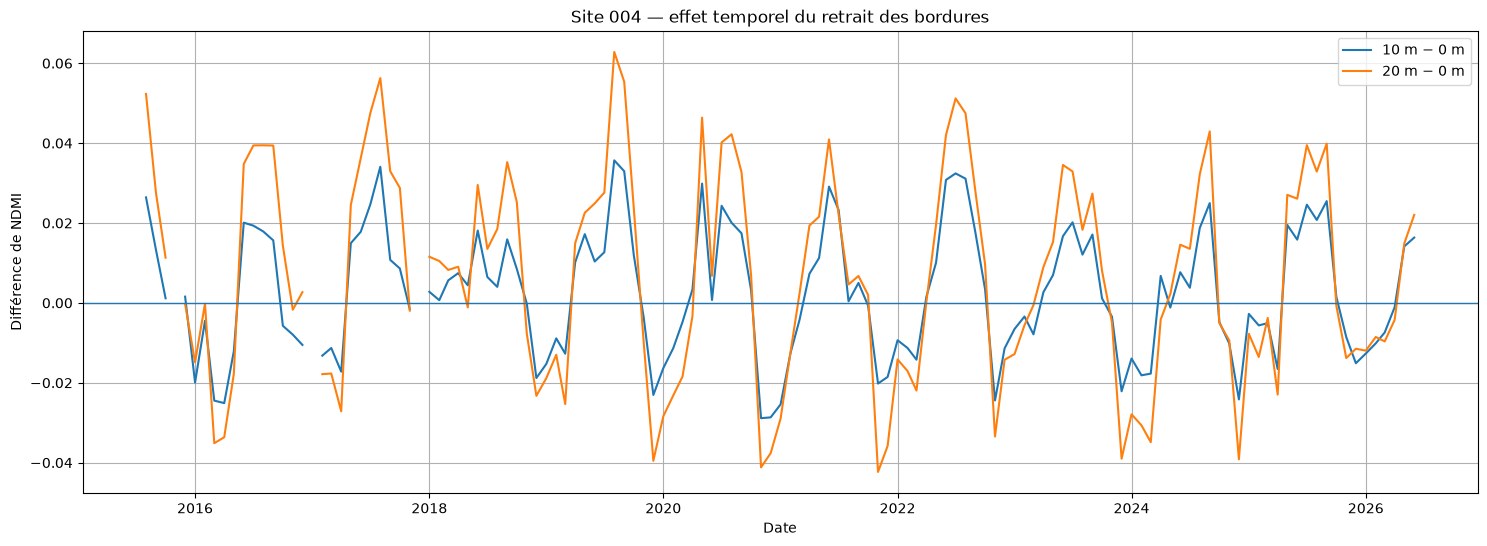

In [94]:
mean_comparison = (
    monthly_border
    .pivot(
        index="acquisition_date",
        columns="buffer_m",
        values="mean",
    )
    .rename(
        columns={
            0: "mean_0m",
            10: "mean_10m",
            20: "mean_20m",
        }
    )
)

mean_comparison["delta_10m"] = (
    mean_comparison["mean_10m"]
    - mean_comparison["mean_0m"]
)

mean_comparison["delta_20m"] = (
    mean_comparison["mean_20m"]
    - mean_comparison["mean_0m"]
)

plt.figure(figsize=(18, 6))

plt.plot(
    mean_comparison.index,
    mean_comparison["delta_10m"],
    label="10 m − 0 m",
)

plt.plot(
    mean_comparison.index,
    mean_comparison["delta_20m"],
    label="20 m − 0 m",
)

plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Différence de NDMI")
plt.title(
    "Site 004 — effet temporel du retrait des bordures"
)
plt.grid()
plt.legend()
plt.show()

In [95]:
print(
    "Première date :",
    border_timeseries["acquisition_date"].min(),
)

print(
    "Dernière date :",
    border_timeseries["acquisition_date"].max(),
)

print(
    "Nombre de dates distinctes :",
    border_timeseries["acquisition_date"].nunique(),
)

print()

print(
    usable_border
    .groupby("buffer_m")
    .agg(
        dates=("acquisition_date", "nunique"),
        pixels_moyens=("valid_pixel_count", "mean"),
        moyenne_ndmi=("mean", "mean"),
        mediane_ndmi=("median", "median"),
    )
)

Première date : 2015-07-30 00:00:00
Dernière date : 2026-06-17 00:00:00
Nombre de dates distinctes : 1479

          dates  pixels_moyens  moyenne_ndmi  mediane_ndmi
buffer_m                                                  
0           677     161.471196      0.215970      0.236968
10          678     130.915929      0.221503      0.246559
20          681     110.107195      0.227499      0.252434


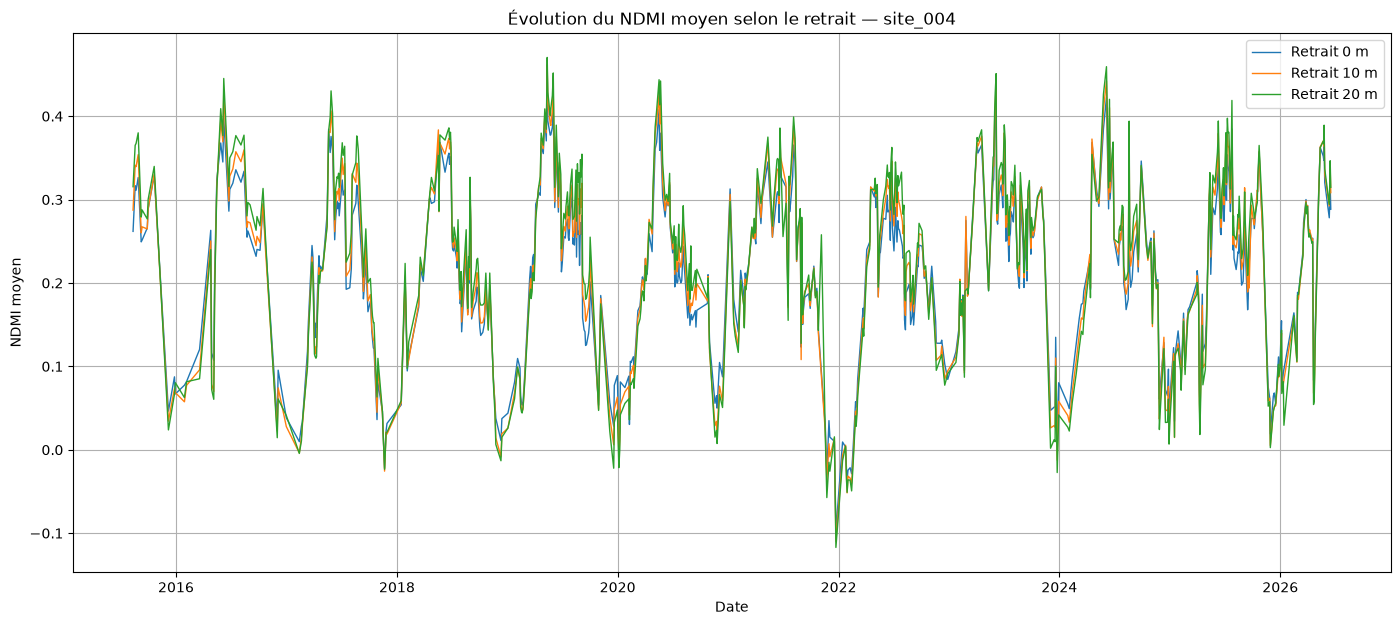

In [96]:
import matplotlib.pyplot as plt


plt.figure(figsize=(17, 7))

for buffer_m in BUFFER_DISTANCES:
    current = border_timeseries[
        (border_timeseries["buffer_m"] == buffer_m)
        & border_timeseries["is_usable"]
    ]

    plt.plot(
        current["acquisition_date"],
        current["mean"],
        linewidth=1,
        label=f"Retrait {buffer_m} m",
    )

plt.xlabel("Date")
plt.ylabel("NDMI moyen")
plt.title(
    f"Évolution du NDMI moyen selon le retrait — {SITE_ID}"
)
plt.grid()
plt.legend()
plt.show()

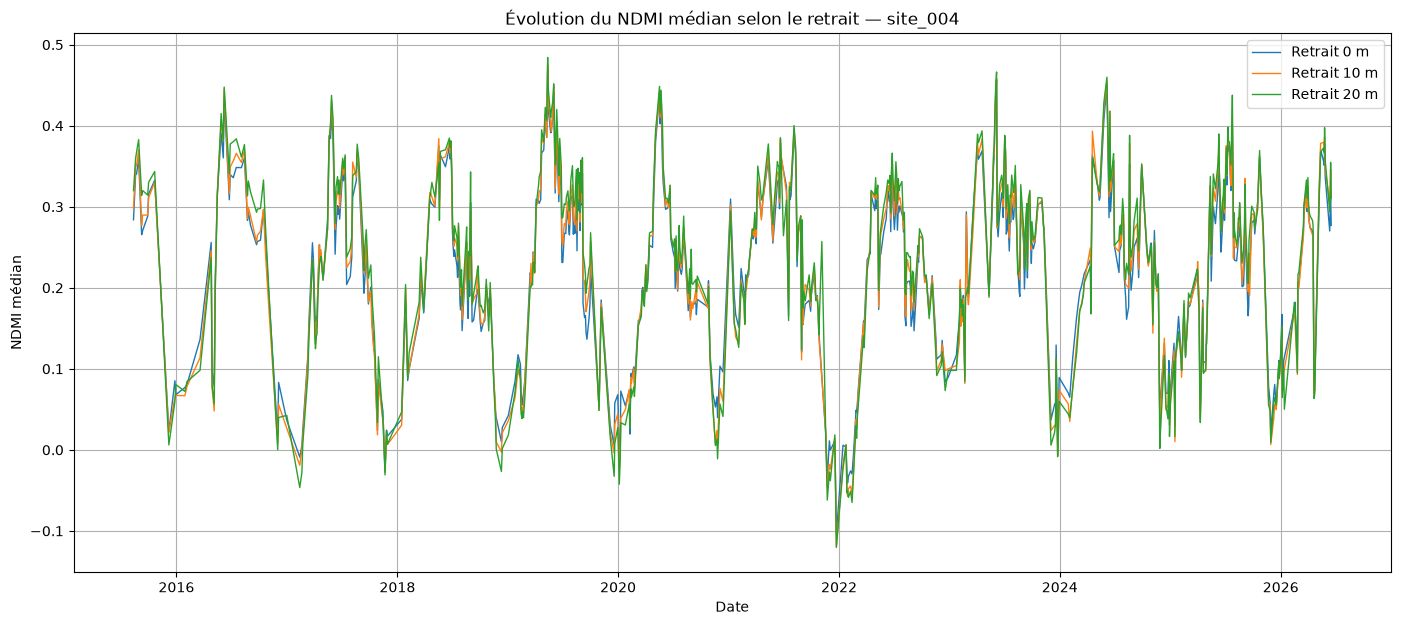

In [97]:
plt.figure(figsize=(17, 7))

for buffer_m in BUFFER_DISTANCES:
    current = border_timeseries[
        (border_timeseries["buffer_m"] == buffer_m)
        & border_timeseries["is_usable"]
    ]

    plt.plot(
        current["acquisition_date"],
        current["median"],
        linewidth=1,
        label=f"Retrait {buffer_m} m",
    )

plt.xlabel("Date")
plt.ylabel("NDMI médian")
plt.title(
    f"Évolution du NDMI médian selon le retrait — {SITE_ID}"
)
plt.grid()
plt.legend()
plt.show()

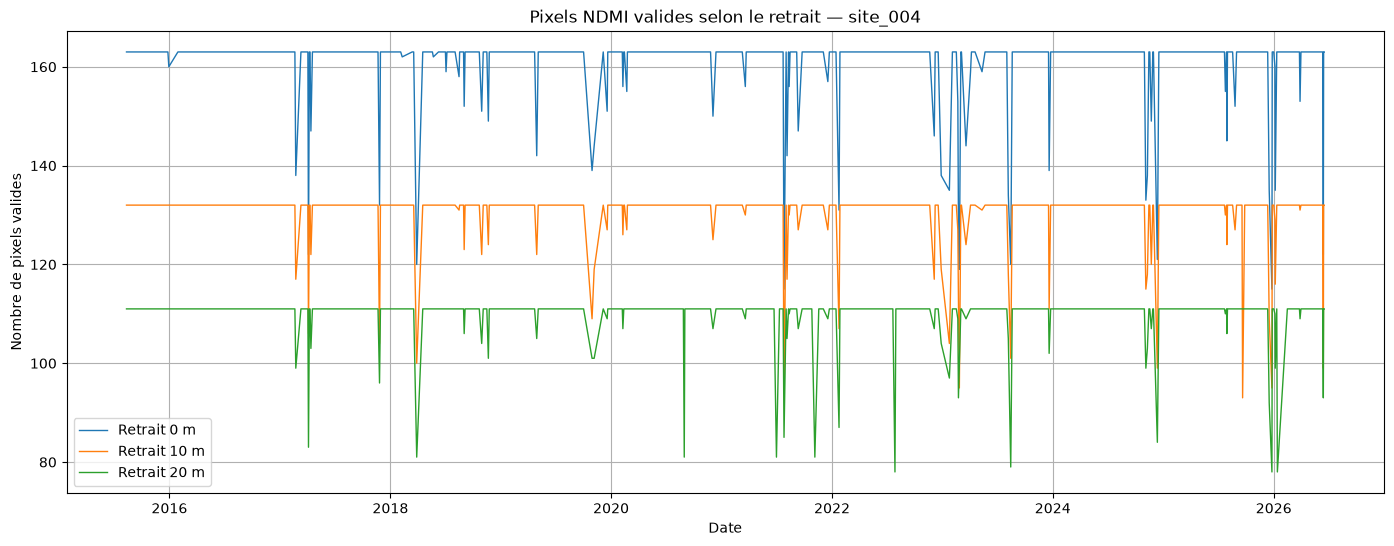

In [98]:
plt.figure(figsize=(17, 6))

for buffer_m in BUFFER_DISTANCES:
    current = border_timeseries[
        (border_timeseries["buffer_m"] == buffer_m)
        & border_timeseries["is_usable"]
    ]

    plt.plot(
        current["acquisition_date"],
        current["valid_pixel_count"],
        linewidth=1,
        label=f"Retrait {buffer_m} m",
    )

plt.xlabel("Date")
plt.ylabel("Nombre de pixels valides")
plt.title(
    f"Pixels NDMI valides selon le retrait — {SITE_ID}"
)
plt.grid()
plt.legend()
plt.show()

In [99]:
monthly_border = (
    common_border
    .set_index("acquisition_date")
    .groupby("buffer_m")
    .resample("MS")
    .agg(
        mean=("mean", "median"),
        median=("median", "median"),
        valid_pixel_count=(
            "valid_pixel_count",
            "median",
        ),
        n_observations=("mean", "count"),
    )
    .reset_index()
)

monthly_border.head()

,buffer_m,acquisition_date,mean,median,valid_pixel_count,n_observations
0,0,2015-08-01,0.313889,0.340218,163.0,4
1,0,2015-09-01,0.251521,0.270195,163.0,3
2,0,2015-10-01,0.308736,0.324101,163.0,2
3,0,2015-11-01,NaN,NaN,NaN,0
4,0,2015-12-01,0.066959,0.068079,163.0,3


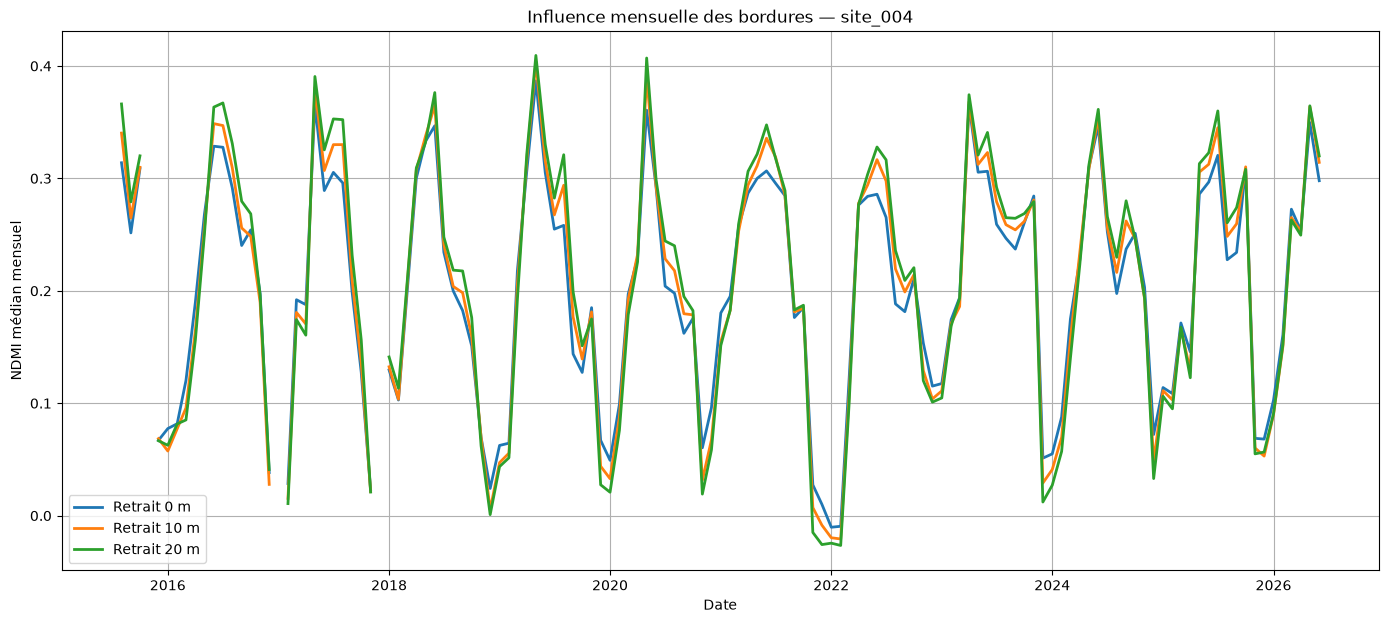

In [100]:
plt.figure(figsize=(17, 7))

for buffer_m in BUFFER_DISTANCES:
    current = monthly_border[
        monthly_border["buffer_m"] == buffer_m
    ]

    plt.plot(
        current["acquisition_date"],
        current["mean"],
        linewidth=2,
        label=f"Retrait {buffer_m} m",
    )

plt.xlabel("Date")
plt.ylabel("NDMI médian mensuel")
plt.title(
    f"Influence mensuelle des bordures — {SITE_ID}"
)
plt.grid()
plt.legend()
plt.show()